# India Data Jobs Market: Structure and Reach

## Decision Question

Where is hiring demand concentrated, and how representative is the available evidence?

This notebook establishes the structure of the Indian data-job market before examining skills or compensation. Job postings are treated as signals of advertised demand rather than completed hires.

The analysis is organized around five questions:

1. Which role families dominate hiring demand?
2. How concentrated is demand across employers?
3. Which locations account for the largest share of postings?
4. How complete is salary information?
5. What limitations should guide interpretation of the dataset?

The findings establish the market baseline used throughout the remainder of the project.

## Data Preparation

The analysis uses the 2023 Data Jobs dataset and restricts observations to postings located in India. Date fields are converted to a standard datetime format to support temporal analysis in later notebooks.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [2]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

india_jobs = df[df["job_country"] == "India"].copy()

print(f"Total dataset postings: {len(df):,}")
print(f"India postings: {len(india_jobs):,}")
print(f"Analysis year: {india_jobs['job_posted_date'].dt.year.mode()[0]}")

assert not india_jobs.empty
assert india_jobs["job_country"].eq("India").all()
assert india_jobs["job_posted_date"].dt.year.nunique() == 1

Total dataset postings: 785,741
India postings: 51,088
Analysis year: 2023


In [3]:
# Notebook-wide visualization settings

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "figure.titlesize": 16,
    "figure.dpi": 110
})

## Evidence Coverage

Before interpreting demand patterns, it is necessary to assess how representative the available evidence is. Coverage is evaluated using posting volume, role diversity, employer diversity, location coverage, remote-work labeling, and salary disclosure rates.

These indicators help determine which conclusions are strongly supported by the dataset and which require additional caution.

In [4]:
coverage = pd.Series(
    {
        "Market postings": len(india_jobs),
        "Share of global dataset": len(india_jobs) / len(df),
        "Distinct roles": india_jobs["job_title_short"].nunique(),
        "Distinct employers": india_jobs["company_name"].nunique(),
        "Distinct location labels": india_jobs["job_location"].nunique(),
        "Remote-labelled postings": india_jobs["job_work_from_home"].mean(),
        "Postings with annual salary": india_jobs["salary_year_avg"].notna().mean(),
    },
    name="Value",
)

coverage_frame = coverage.to_frame()

coverage_display = coverage_frame.astype(object)

count_metrics = [
    "Market postings",
    "Distinct roles",
    "Distinct employers",
    "Distinct location labels",
]

percentage_metrics = [
    "Share of global dataset",
    "Remote-labelled postings",
    "Postings with annual salary",
]

coverage_display.loc[count_metrics, "Value"] = (
    coverage_frame.loc[count_metrics, "Value"]
    .astype(int)
    .map(lambda value: f"{value:,}")
)

coverage_display.loc[percentage_metrics, "Value"] = (
    coverage_frame.loc[percentage_metrics, "Value"]
    .map(lambda value: f"{value:.1%}")
)

display(
    coverage_display.reset_index()
    .rename(columns={"index": "Metric"})
    .style.hide(axis="index")
    .set_properties(
        subset=["Metric", "Value"],
    )
)

assert coverage["Market postings"] == len(india_jobs)
assert coverage["Distinct roles"] > 0
assert coverage["Distinct employers"] > 0

Metric,Value
Market postings,"51,088"
Share of global dataset,6.5%
Distinct roles,10
Distinct employers,"12,857"
Distinct location labels,534
Remote-labelled postings,11.2%
Postings with annual salary,1.1%


The dataset contains enough India postings to compare broad demand patterns, but salary disclosure is too sparse to support market-wide compensation estimates without qualification.

## Role Concentration

Role share is more informative than raw volume because it shows how demand is distributed across the market. Cumulative share indicates how quickly demand concentrates among a small number of role categories.

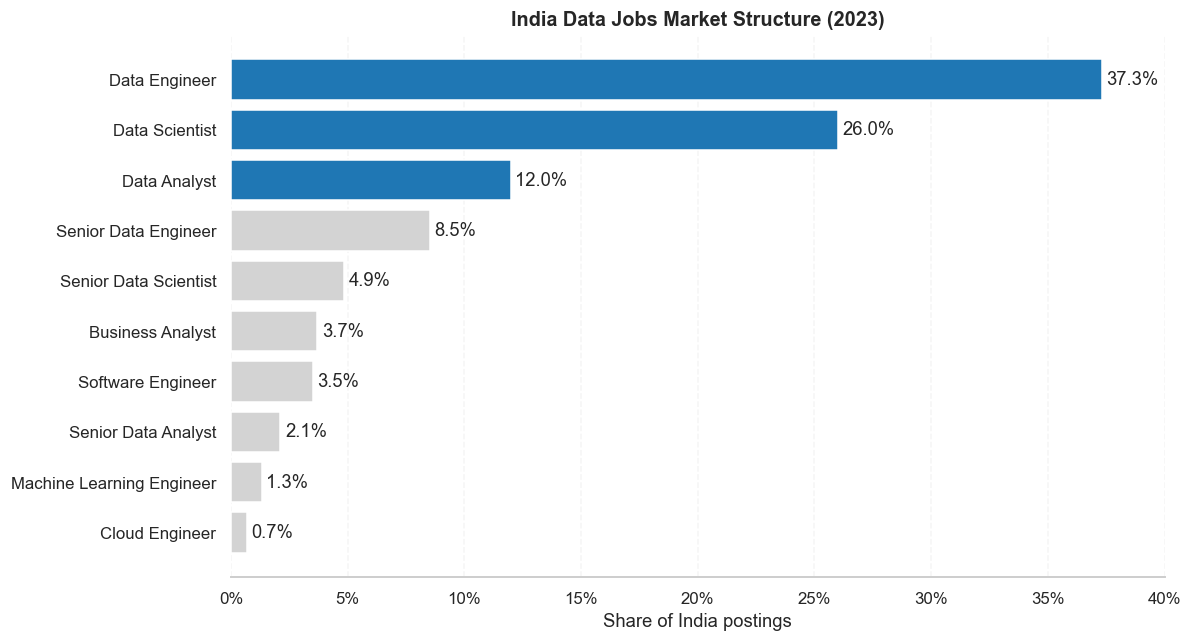

Rank,Role,Postings,Share,Cum. Share
1,Data Engineer,"19,062",37.3%,37.3%
2,Data Scientist,"13,279",26.0%,63.3%
3,Data Analyst,"6,121",12.0%,75.3%
4,Senior Data Engineer,"4,353",8.5%,83.8%
5,Senior Data Scientist,"2,486",4.9%,88.7%
6,Business Analyst,"1,887",3.7%,92.4%
7,Software Engineer,"1,795",3.5%,95.9%
8,Senior Data Analyst,"1,083",2.1%,98.0%
9,Machine Learning Engineer,671,1.3%,99.3%
10,Cloud Engineer,351,0.7%,100.0%


In [5]:
role_mix = (
    india_jobs["job_title_short"]
    .value_counts()
    .rename_axis("role")
    .reset_index(name="postings")
)

role_mix["share"] = role_mix["postings"] / role_mix["postings"].sum()
role_mix["cumulative_share"] = role_mix["share"].cumsum()
role_mix["rank"] = range(1, len(role_mix) + 1)

top_roles = role_mix.head(10).copy()
top3_share = top_roles.head(3)["share"].sum()

# ------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------

plot_data = top_roles.sort_values("share")

highlight_roles = {
    "Data Engineer",
    "Data Scientist",
    "Data Analyst",
}

plot_data["color"] = plot_data["role"].apply(
    lambda role: "#1f77b4" if role in highlight_roles else "#d3d3d3"
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    plot_data["role"],
    plot_data["share"],
    color=plot_data["color"],
)

ax.set_xlim(0, 0.40)
ax.xaxis.set_major_formatter(
    lambda value, _: f"{value:.0%}"
)

ax.set(
    title="India Data Jobs Market Structure (2023)",
    xlabel="Share of India postings",
    ylabel="",
)

ax.bar_label(
    bars,
    labels=[f"{value:.1%}" for value in plot_data["share"]],
    padding=3,
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20,
)
ax.grid(axis="y", visible=False)

sns.despine(left=True, top=True, right=True)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------

summary_table = (
    top_roles[
        ["rank", "role", "postings", "share", "cumulative_share"]
    ]
    .copy()
    .rename(
        columns={
            "rank": "Rank",
            "role": "Role",
            "postings": "Postings",
            "share": "Share",
            "cumulative_share": "Cum. Share",
        }
    )
)

summary_table["Postings"] = summary_table["Postings"].map("{:,}".format)
summary_table["Share"] = summary_table["Share"].map("{:.1%}".format)
summary_table["Cum. Share"] = (
    summary_table["Cum. Share"]
    .map("{:.1%}".format)
)

display(
    summary_table.style
    .hide(axis="index")
    .set_properties(
        subset=["Rank"],
        **{"font-weight": "bold"}
    )
    .set_properties(
        subset=["Role"],
    )
)

Data Engineering is the largest role family, followed by Data Science and Data Analysis. Together they represent 75.3% of postings. The concentration of postings in Data Engineering and Data Science suggests that technical platform-building and modeling capabilities account for a large share of observed hiring demand.

## Geographic and Employer Concentration

Location concentration identifies where the largest pools of data-job demand are located. Employer concentration tests whether demand depends on a small set of firms.

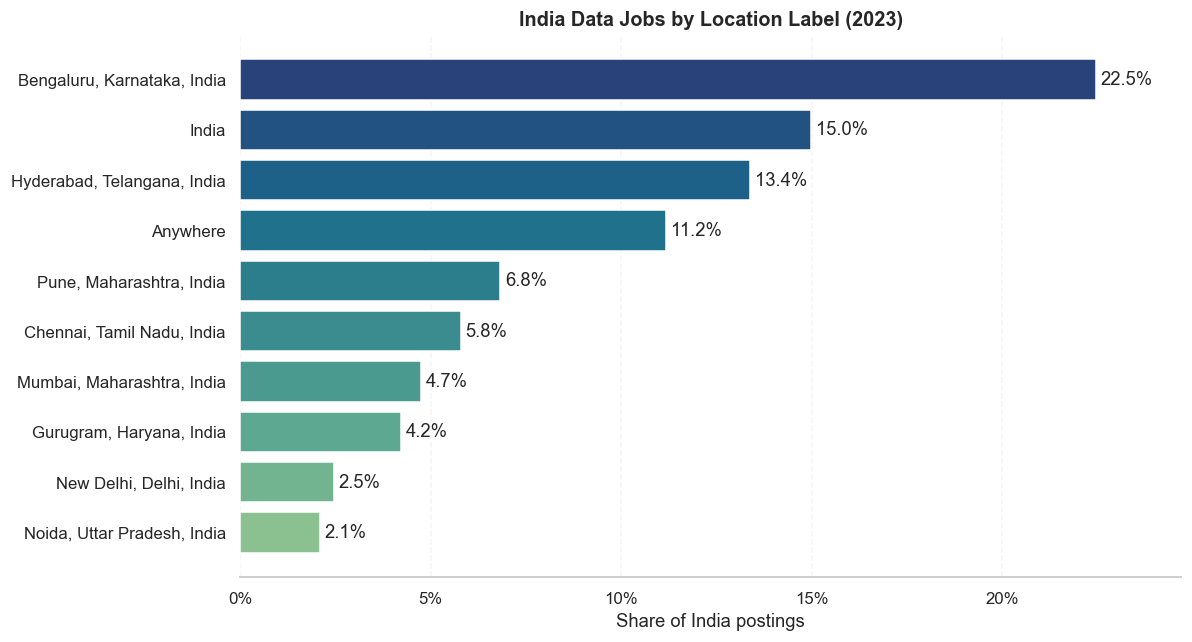

Metric,Value
Top 3 Role Share,75.3%
Top 5 Location-Label Share,68.9%
Top 10 Employer Share,5.8%
"Employer HHI (0–10,000)",9


In [6]:
# ------------------------------------------------------------------
# Geographic and employer concentration
# ------------------------------------------------------------------

location_mix = (
    india_jobs["job_location"]
    .value_counts()
    .head(10)
    .sort_values()
)

# ------------------------------------------------------------------
# Concentration metrics
# ------------------------------------------------------------------

top3_role_share = (
    india_jobs["job_title_short"]
    .value_counts(normalize=True)
    .head(3)
    .sum()
)

top5_location_share = (
    india_jobs["job_location"]
    .value_counts(normalize=True)
    .head(5)
    .sum()
)

top10_employer_share = (
    india_jobs["company_name"]
    .value_counts(normalize=True)
    .head(10)
    .sum()
)

employer_shares = (
    india_jobs["company_name"]
    .value_counts(normalize=True)
)

employer_hhi = (
    employer_shares.pow(2).sum()
    * 10_000
)

concentration = pd.Series(
    {
        "Top 3 Role Share": top3_role_share,
        "Top 5 Location-Label Share": top5_location_share,
        "Top 10 Employer Share": top10_employer_share,
        "Employer HHI (0–10,000)": employer_hhi,
    },
    name="Value",
)

# ------------------------------------------------------------------
# Location-label concentration chart
# ------------------------------------------------------------------

location_share = location_mix / len(india_jobs)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    location_share.index,
    location_share.values,
    color=sns.color_palette("crest", len(location_share)),
)

ax.xaxis.set_major_formatter(
    lambda value, _: f"{value:.0%}"
)
ax.set_xlim(0, location_share.max() * 1.10)

ax.set(
    title="India Data Jobs by Location Label (2023)",
    xlabel="Share of India postings",
    ylabel="",
)

ax.bar_label(
    bars,
    labels=[f"{value:.1%}" for value in location_share],
    padding=3,
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20,
)
ax.grid(axis="y", visible=False)

sns.despine(left=True, top=True, right=True)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Concentration summary table
# ------------------------------------------------------------------

concentration_table = (
    concentration
    .to_frame()
    .reset_index()
)

concentration_table.columns = [
    "Metric",
    "Value",
]

display(
    concentration_table.style
    .hide(axis="index")
    .format(
        {
            "Value": (
                lambda value:
                f"{value:.1%}"
                if value <= 1
                else f"{value:,.0f}"
            )
        }
    )
)

Job demand is concentrated across a limited number of role families and location labels, whereas hiring activity is distributed across a highly fragmented employer base.

Bengaluru is the largest named hub. Hyderabad, Pune, Chennai, and Mumbai also contribute material volume, while `India` and `Anywhere` capture postings without a precise city. Employer demand is highly fragmented: the top ten firms contribute only 5.8% of postings and the employer HHI is 9, far below levels associated with concentration.

**Why it matters:** candidates can target a few geographic hubs, but should not build an employer strategy around only the most visible companies.

## Implications

- **Market positioning:** Technical role families dominate advertised demand; Data Engineer roles account for 37.3% of India data-job postings in the dataset.
- **Search strategy:** geography matters, but location labels are imperfect. A city-focused search should include generic India and remote postings.
- **Evidence hierarchy:** role, location, and skill prevalence are supported by substantial samples. Salary evidence is sparse and should be treated as directional.

## Limitations

- The dataset measures postings, not hires, applicants, or vacancies filled.
- Duplicate or syndicated postings may inflate activity.
- Employer and location names are not fully standardized.
- The dataset covers calendar year 2023; it does not establish current market conditions.
- Salary is reported as standardized annual USD and is missing for 98.9% of India postings.